In [3]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt


# Projeto 4 - Sinais e Sistemas em Tempo Discreto - 2023/01
# Identificação
## Nome: Raul Myron Silva Amorim
## Matrícula: 200049712

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [4]:
def dft(x):
    """DFT pela definição: X[k] = soma x[n] W^(kn), W = e^(-j2pi/N)."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    n = np.arange(N)
    k = n.reshape(-1, 1)
    W = np.exp(-1j*2*np.pi/N)
    return (x * W**(k*n)).sum(axis=1)

def fir_freq_sampling(N, fc, Fs, centralizar=False):
    """Projeta um FIR passa-baixas por amostragem em frequência (Questão 3)."""
    k = np.arange(N)
    f_k = k*Fs/N
    Hd = np.where((f_k <= fc) | (f_k >= Fs - fc), 1.0, 0.0)  # ideal, com simetria
    if centralizar:
        Hd = Hd * np.exp(-1j*2*np.pi*k*(N-1)/(2*N))  # e^(-jΩ(N-1)/2) amostrado
    h = np.fft.ifft(Hd).real  # descarta componente imaginária residual
    return h

def filtra_janela(x_jan, h, Nfft):
    """Filtra uma janela no domínio da DFT (Questão 2b)."""
    X = np.fft.fft(x_jan, Nfft)
    H = np.fft.fft(h, Nfft)
    return np.fft.ifft(X * H).real

def overlap_add(x, h, L):
    """Combina as janelas filtradas pelo método OVERLAP-AND-ADD (Questão 2c)."""
    M = len(h)
    Nfft = int(2**np.ceil(np.log2(L + M - 1)))  # evita convolução circular
    y = np.zeros(len(x) + M - 1)
    for i in range(0, len(x), L):
        bloco = x[i:i+L]
        y_bloco = filtra_janela(bloco, h, Nfft)[:len(bloco) + M - 1]
        y[i:i+len(y_bloco)] += y_bloco  # soma as "caudas" sobrepostas
    return y[:len(x)]

# Questão 1

Considere um sinal $x\left[n\right]$ com 16 amostras:

$$
x\left[n\right] = \left\{ 1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 6, 5, 4, 3, 2, 1\right\}
$$


## Questão 1a (1.0 ponto)

Calcule a DFT do sinal através da equação:

$$
X\left[k\right] = \sum_{n = 0}^{N-1} x\left[n\right] W_{N}^{kn}
$$

com $W_{N} = e^{-\frac{2 \pi}{N}}$.

X[ 0] = 72.0000+0.0000j
X[ 1] = -25.2741-5.0273j
X[ 2] = 0.0000+0.0000j
X[ 3] = -2.2398-1.4966j
X[ 4] = 0.0000+0.0000j
X[ 5] = -0.4465-0.6682j
X[ 6] = 0.0000+0.0000j
X[ 7] = -0.0396-0.1989j
X[ 8] = 0.0000-0.0000j
X[ 9] = -0.0396+0.1989j
X[10] = -0.0000+0.0000j
X[11] = -0.4465+0.6682j
X[12] = -0.0000-0.0000j
X[13] = -2.2398+1.4966j
X[14] = -0.0000-0.0000j
X[15] = -25.2741+5.0273j


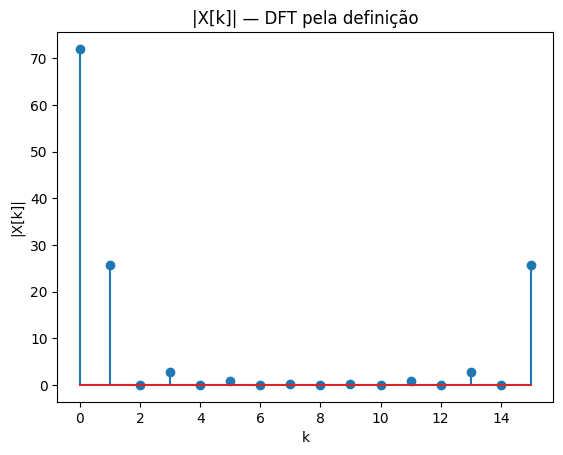

In [5]:
x = np.array([1,2,3,4,5,6,7,8,8,7,6,5,4,3,2,1], dtype=float)
N = len(x)

X = dft(x)
for k in range(N):
    print(f'X[{k:2d}] = {X[k]:.4f}')

plt.stem(np.arange(N), np.abs(X))
plt.title('|X[k]| — DFT pela definição')
plt.xlabel('k'); plt.ylabel('|X[k]|')
plt.show()

## Questão 1b (1.0 ponto)

Considere a separação do sinal $x\left[n\right]$ em suas amostras pares e ímpares, $x_e\left[n\right]$ e $x_o\left[n\right]$, respectivamente. 

Calcule a DFT do sinal $x\left[n\right]$ através da equação:

$$
\hat{X}\left[k\right] = X_e\left[k\right] + W_{N}^{k} X_o\left[k\right]
$$

Compare as duas DFTs e calcule o erro médio absoluto (MAE) entre as DFTs calculadas pelas duas formas:

$$
MAE = \sum_{i = 0}^{N-1} \left| X\left[i\right] - \hat{X}\left[i\right]\right|
$$

MAE = 4.08e-13


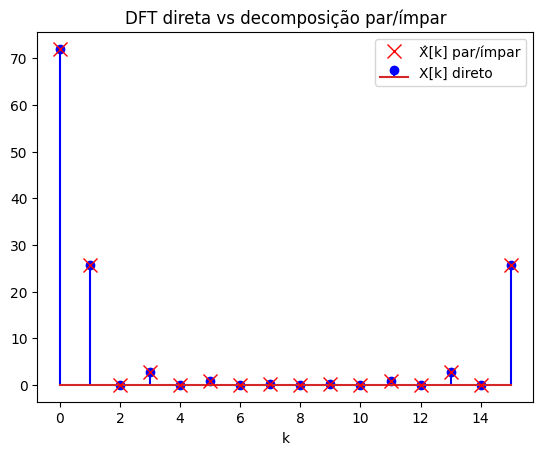

In [6]:
xe = x[::2]
xo = x[1::2]

Xe = dft(xe)
Xo = dft(xo)

k = np.arange(N)
W = np.exp(-1j*2*np.pi/N)
Xhat = Xe[k % (N//2)] + W**k * Xo[k % (N//2)]

MAE = np.sum(np.abs(X - Xhat))
print(f'MAE = {MAE:.2e}')

plt.stem(k, np.abs(X), linefmt='b-', markerfmt='bo', label='X[k] direto')
plt.plot(k, np.abs(Xhat), 'rx', markersize=10, label='X̂[k] par/ímpar')
plt.legend(); plt.xlabel('k')
plt.title('DFT direta vs decomposição par/ímpar')
plt.show()

O MAE entre a DFT direta e a obtida pela decomposição par/ímpar é $\approx 10^{-13}$ — ou seja, **zero a menos do erro de ponto flutuante**. As duas são matematicamente idênticas.
 
A relação $\hat{X}[k] = X_e[k] + W_N^k \, X_o[k]$ é exatamente o passo de *decimação no tempo* que fundamenta o algoritmo FFT. É esse "dividir para conquistar" recursivo que reduz o custo de $O(N^2)$ (a DFT pela definição) para $O(N \log N)$.

# Questão 2

O arquivo "potencia.txt" contém dados da envoltória real de um tom senoidal amostrado a uma taxa de $200$ amostras / segundo. Para a separação do desvanecimento em larga escala é necessário filtrar esse sinal com um filtro passa-baixas com frequência de corte em torno de $5$ Hz.


## Questão 2a (1.0  ponto)

Projete um filtro digital com a especificação desejada. Podem ser utilizadas as funções de design de filtro da PySDR (https://pysdr.org/content/filters.html), da própria biblioteca scipy (https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) ou mesmo bibliotecas web (http://t-filter.engineerjs.com/) . Plote a resposta em frequência e a resposta ao impulso do filtro projetado. 

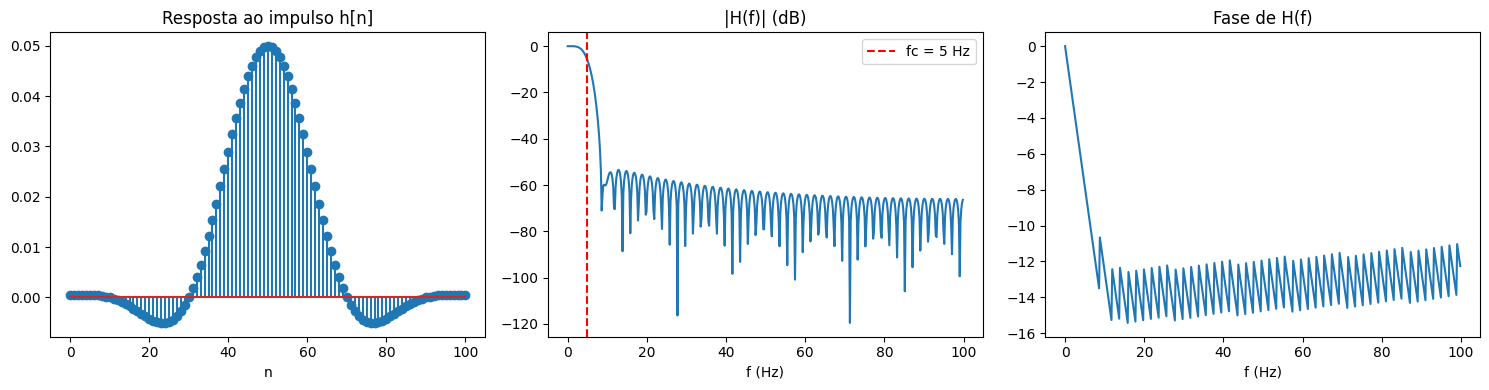

In [7]:
#Resposta da questão 2a

Fs = 200
fc = 5
M = 101

h = sp.signal.firwin(M, fc, fs=Fs)

# Resposta em frequência

w, H = sp.signal.freqz(h, 1, fs=Fs)

fig, axs = plt.subplots(1, 3, figsize=(15,4))
axs[0].stem(np.arange(M), h)
axs[0].set_title('Resposta ao impulso h[n]')
axs[0].set_xlabel('n')

axs[1].plot(w, 20*np.log10(np.abs(H) + 1e-12))
axs[1].axvline(fc, color='r', linestyle='--', label='fc = 5 Hz')
axs[1].set_title('|H(f)| (dB)'); axs[1].set_xlabel('f (Hz)'); axs[1].legend()

axs[2].plot(w, np.unwrap(np.angle(H)))
axs[2].set_title('Fase de H(f)'); axs[2].set_xlabel('f (Hz)')
plt.tight_layout(); plt.show()

## Questão 2b (1.0 ponto)

Escreva uma função para processar uma janela de $N$ amostras do sinal desejado. $N$ deve ser escolhido em torno de 1 segundo de sinal, aproximadamente. A filtragem deve ser feita no domínio da DFT (pode ser utilizada alguma função para cálculo da fft em Python, como a função fft da biblioteca numpy).

In [9]:
#Resposta da questão 2b
L = 200  # ~1 segundo de sinal a 200 amostras/s
Nfft = int(2**np.ceil(np.log2(L + M - 1)))  # 512 evita aliasing
print(f'Janela L = {L} amostras (1 s), Nfft = {Nfft}')

Janela L = 200 amostras (1 s), Nfft = 512


## Questão 2c (1.0  ponto)

Escreva uma função para combinar a saída do processamento de cada janela na saída do sistema, utilizando **um** dos métodos vistos (*overlap and add* ou *overlap and save*). Indique claramente o método escolhido.


In [10]:
#Resposta da questão 2c

sinal = np.loadtxt("potencia.txt")

# MÉTODO ESCOLHIDO: OVERLAP-AND-ADD
# Cada bloco de L amostras é filtrado via DFT (com zero-padding até Nfft),
# gerando um bloco de saída de L+M-1 amostras. As "caudas" de M-1 amostras
# que ultrapassam o bloco são SOMADAS ao início do bloco seguinte.

y_janelas = overlap_add(sinal, h, L=200)
print(f'Sinal: {len(sinal)} amostras -> saída: {len(y_janelas)} amostras')

Sinal: 8001 amostras -> saída: 8001 amostras


## Questão 2d (1.0  ponto)

Plote o sinal de entrada e saída do sistema dado tanto pelo processamento em janelas como pelo processamento do sinal completo. Pode ser utilizada alguma função da biblioteca do python para calcular a saída do sistema usando o sinal completo.

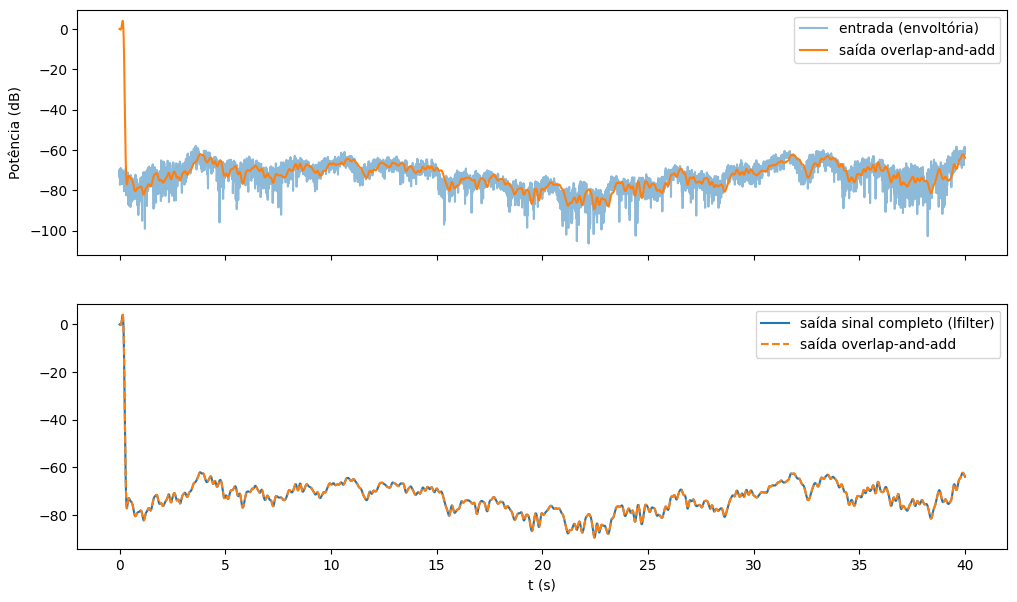

Erro máximo entre os dois métodos: 5.68e-14


In [11]:
#Resposta da questão 2d
y_completo = sp.signal.lfilter(h, 1, sinal)

t = np.arange(len(sinal))/Fs

fig, axs = plt.subplots(2, 1, figsize=(12,7), sharex=True)
axs[0].plot(t, sinal, alpha=0.5, label='entrada (envoltória)')
axs[0].plot(t, y_janelas, label='saída overlap-and-add')
axs[0].legend(); axs[0].set_ylabel('Potência (dB)')

axs[1].plot(t, y_completo, label='saída sinal completo (lfilter)')
axs[1].plot(t, y_janelas, '--', label='saída overlap-and-add')
axs[1].legend(); axs[1].set_xlabel('t (s)')
plt.show()

erro = np.abs(y_janelas - y_completo).max()
print(f'Erro máximo entre os dois métodos: {erro:.2e}')

# Questão 3

A equação diferença para um filtro FIR de tamanho $N$ pode ser escrita como:

$$
\begin{align}
	y\left[n\right] &= h_0 x\left[n\right] + h_1 x\left[n-1\right] + h_2 x\left[n-2\right] + h_3 \left[n-3\right] + \ldots + h_{N-1} x\left[n - \left(N- 1\right)\right] \\
	       &= \sum_{k=0}^{N-1} h_k x\left[n - k\right] 
\end{align}
$$

Os coeficientes do filtro, ou \textit{taps}, são expressados usando a variável $h_k$ para enfatizar que os próprios coeficientes representam a resposta ao impulso do filtro. A resposta em frequência do filtro é:

$$
\begin{align}
	H\left( \Omega \right) = \frac{Y\left( \Omega \right)}{X\left( \Omega \right)} = \sum_{k=0}^{N-1} h_k e^{-j \Omega k}
\end{align}
$$

Como $H\left( \Omega \right)$ é uma função com período $2 \pi$ da variável contínua $\Omega$, é suficiente especificar $H\left( \Omega \right)$ em apenas um período $0 \leq \Omega < 2 \pi$. 

Em muitas aplicações, a resposta em magnitude desejada do filtro $\left|H_d \left( \Omega \right)\right|$ é conhecida, mas não os coeficientes $h_k$ do filtro. A questão é, então, determinar os coeficientes do filtro a partir da resposta em magnitude desejada. Podemos fazer isso simplesmente amostrando a resposta em frequência desejada $\left|H_d \left( \Omega \right)\right|$ com $N$ amostras em um período, e então fazendo a DFT inversa dessas amostras (obtendo $h\left[n\right]$). Note que a definição dos coeficientes $h_k$ é suficiente para determinar o sistema do filtro FIR. Além disso, como $H \left( \Omega \right)$ foi obtido amostrando $\left|H_d \left( \Omega \right)\right|$ para algumas frequências, garantimos que a resposta em frequência do filtro projeto será igual a resposta em frequência desejada ao menos nos valores de amostragem. Finalmente, observe que, ao fazer a DFT inversa, alguns coeficientes $h_k$ podem ter uma pequena componente imaginária que deve ser descartada para o projeto de um filtro real. 



## Questão 3a (1.0  ponto)

Considere então um sinal de ECG amostrado a uma taxa de $500$ Hz. Projete um filtro digital FIR através da amostragem de frequência passa-baixas com frequência de corte igual a $50$ Hz. 

Plote a resposta ao impulso $h\left[n\right]$ e a resposta em frequência $H\left(\Omega\right)$ do filtro para $N = 21$, $N = 31$ e $N = 41$. Compare os filtros com a resposta em frequência desejada. 

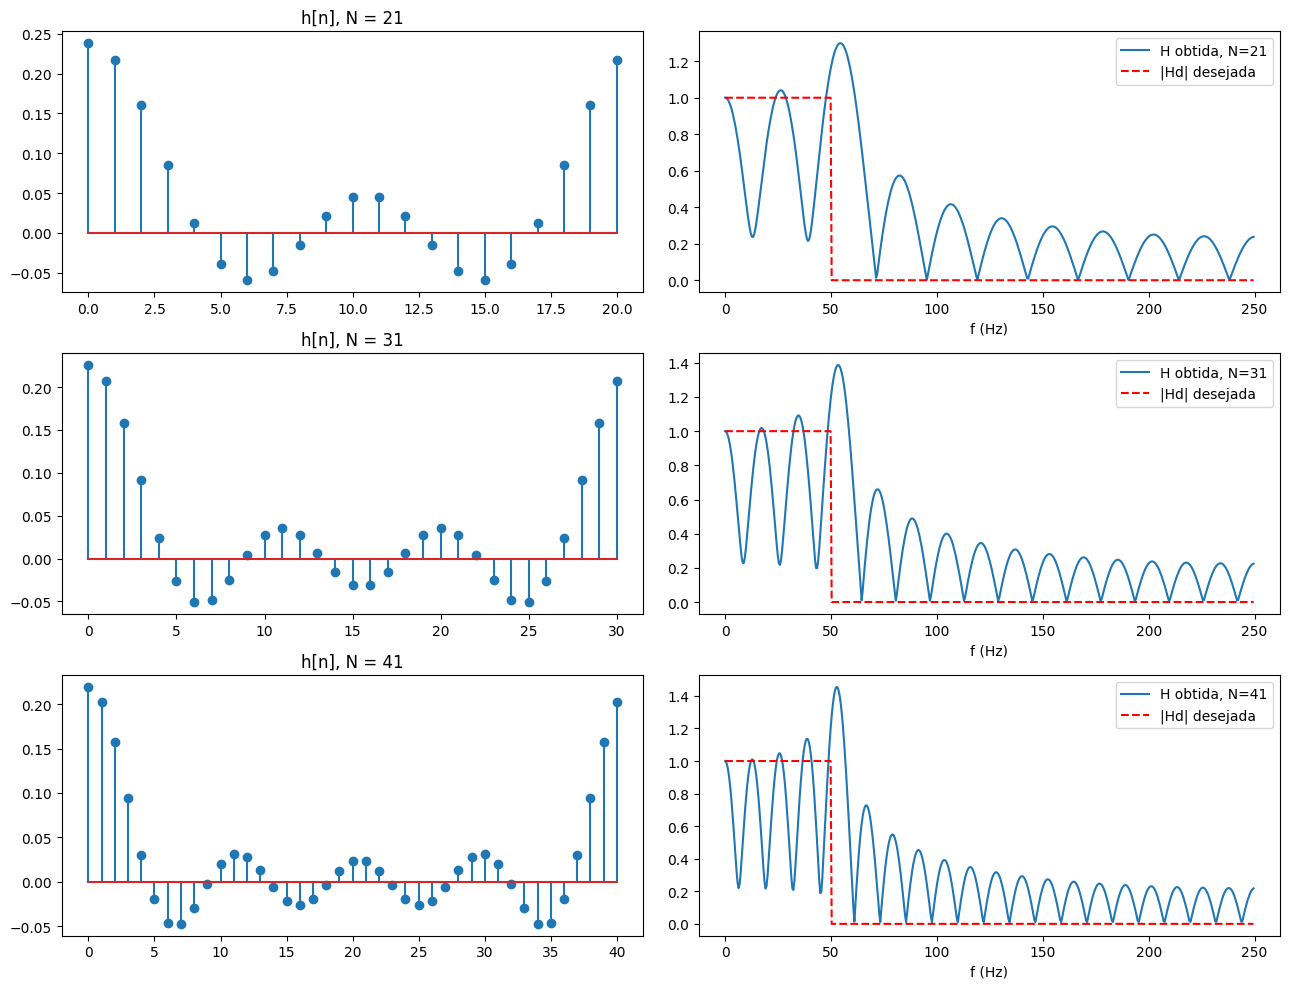

In [12]:
#Resposta da questão 3a
Fs3 = 500
fc3 = 50

fig, axs = plt.subplots(3, 2, figsize=(13,10))
for i, Nf in enumerate([21, 31, 41]):
    h_n = fir_freq_sampling(Nf, fc3, Fs3)
    w3, H3 = sp.signal.freqz(h_n, 1, fs=Fs3)

    axs[i,0].stem(np.arange(Nf), h_n)
    axs[i,0].set_title(f'h[n], N = {Nf}')

    axs[i,1].plot(w3, np.abs(H3), label=f'H obtida, N={Nf}')
    Hd_plot = np.where(w3 <= fc3, 1.0, 0.0)
    axs[i,1].plot(w3, Hd_plot, 'r--', label='|Hd| desejada')
    axs[i,1].legend(); axs[i,1].set_xlabel('f (Hz)')
plt.tight_layout(); plt.show()

A resposta obtida passa **exatamente** pelos pontos amostrados de $|H_d|$ (garantido por construção — foi assim que os coeficientes foram gerados), mas entre as amostras ela oscila bastante, deixando a banda de rejeição pobre (vazamento de $\approx 0{,}4$ no pior ponto).
 
Curiosamente, aumentar $N$ quase não melhora esse caso, porque a resposta ao impulso — uma sinc — está sendo amostrada apenas para $n \ge 0$, criando uma descontinuidade abrupta na borda da janela.

## Questão 3b (1.0  ponto)

A resposta ao impulso do filtro do item anterior deveria ser uma função *sinc*, que é uma função com suporte infinito. Porém, a amostragem amostra apenas a parte para $n$ positivo, gerando uma descontinuidade e uma resposta em frequência mais pobre. Uma forma de melhorar essa amostragem é centralizar a função *sinc* - para isso, devemos multiplicar a resposta em frequência do filtro $H\left(\Omega\right)$ por $e^{-j \Omega \frac{\left(N - 1\right)}{2}}$. Utilize essa técnica para gerar novos filtros com $N = 21$, $N = 31$ e $N = 41$. Compare os filtros com os filtros do item anterior com o mesmo tamanho.

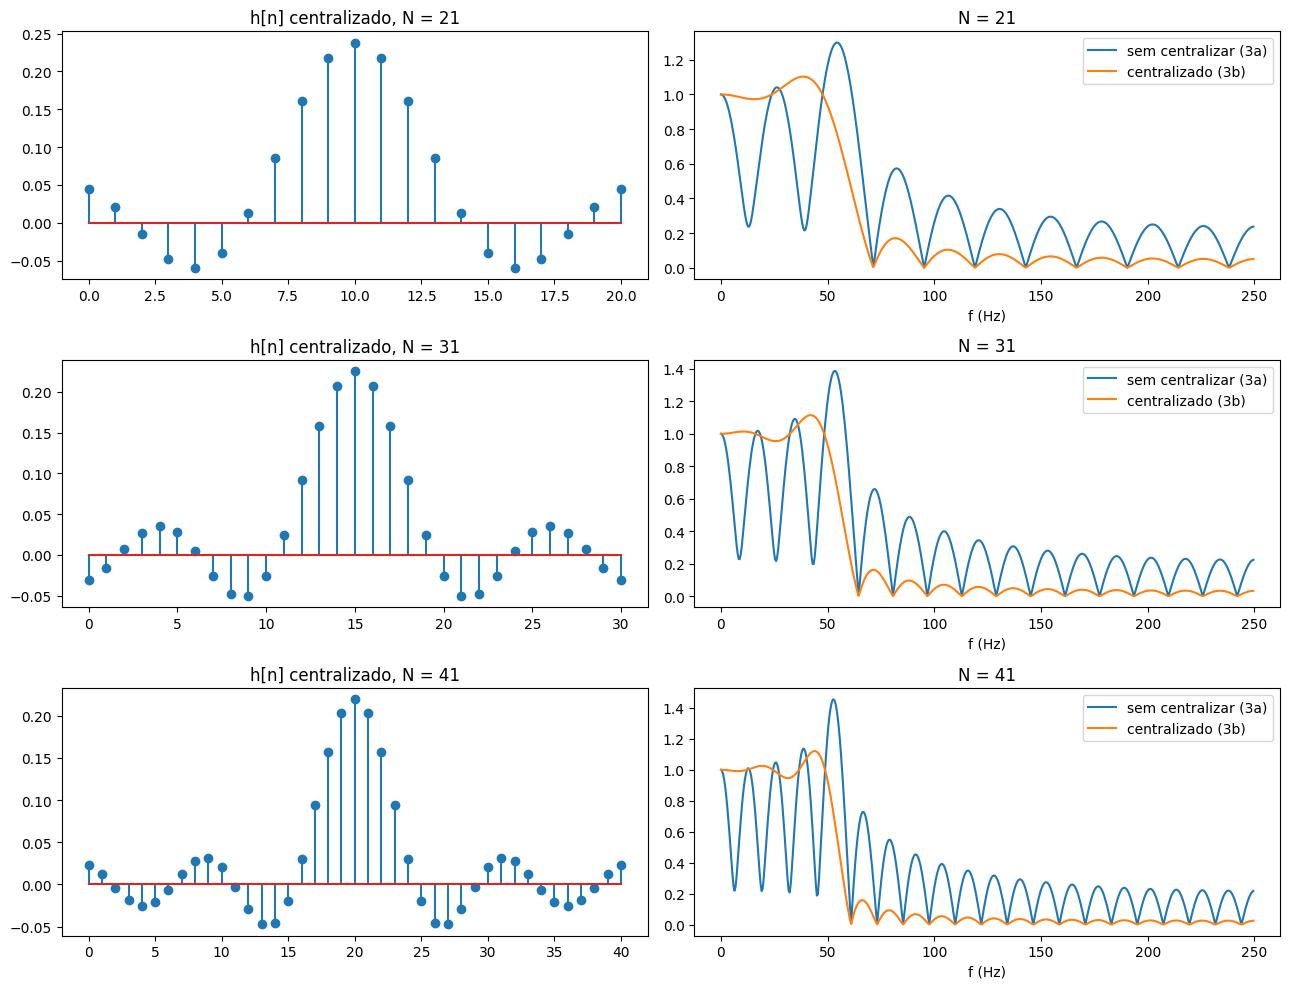

In [13]:
#Resposta da questão 3b
fig, axs = plt.subplots(3, 2, figsize=(13,10))
for i, Nf in enumerate([21, 31, 41]):
    h_sem  = fir_freq_sampling(Nf, fc3, Fs3, centralizar=False)
    h_com  = fir_freq_sampling(Nf, fc3, Fs3, centralizar=True)
    w3, H_sem = sp.signal.freqz(h_sem, 1, fs=Fs3)
    _,  H_com = sp.signal.freqz(h_com, 1, fs=Fs3)

    axs[i,0].stem(np.arange(Nf), h_com)
    axs[i,0].set_title(f'h[n] centralizado, N = {Nf}')

    axs[i,1].plot(w3, np.abs(H_sem), label='sem centralizar (3a)')
    axs[i,1].plot(w3, np.abs(H_com), label='centralizado (3b)')
    axs[i,1].legend(); axs[i,1].set_title(f'N = {Nf}'); axs[i,1].set_xlabel('f (Hz)')
plt.tight_layout(); plt.show()

Multiplicar $H(\Omega)$ por $e^{-j\Omega(N-1)/2}$ desloca a sinc para o **centro** da janela, eliminando a descontinuidade da borda e tornando o filtro de **fase linear**.
 
A rejeição melhora drasticamente — o pior vazamento na banda de rejeição cai de $0{,}39$ para $0{,}05$ em $N = 41$ ($\approx 7\times$ melhor). E agora aumentar $N$ de fato ajuda:
 
| $N$ | vazamento (stopband) |
|-----|----------------------|
| 21  | $0{,}10$             |
| 31  | $0{,}07$             |
| 41  | $0{,}05$             |
 
O custo é um atraso de grupo de $(N-1)/2$ amostras.

## Questão 3c (1.0  ponto)

Aplique o filtro com $N = 41$ no sinal do arquivo "noisy\_ecg\_data\_3.mat". Compare o sinal de entrada com o sinal de saída. O que acontece com os picos do ECG? 

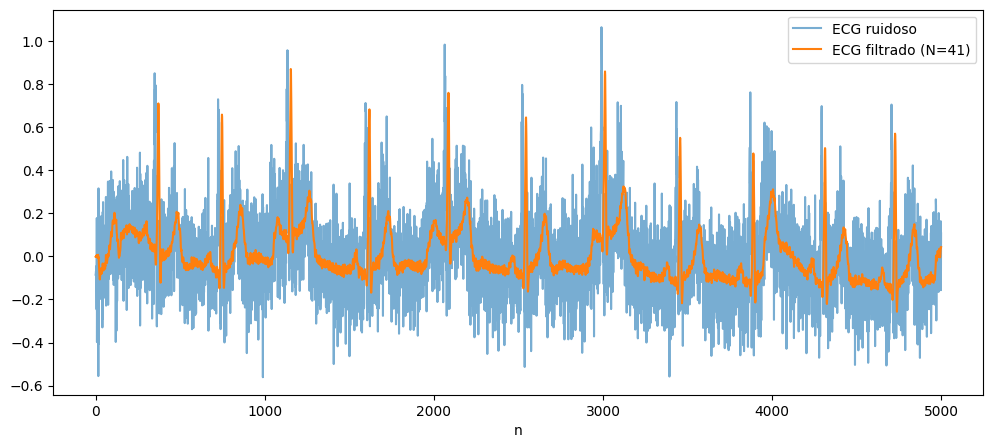

Pico original: 1.065 | pico filtrado: 0.870


In [14]:
#Resposta da questão 3c

sinal = sp.io.loadmat('noisy_ecg_data_3.mat')['noisy_ecg_3'].ravel()

h41 = fir_freq_sampling(41, fc3, Fs3, centralizar=True)
y_ecg = sp.signal.lfilter(h41, 1, sinal)

plt.figure(figsize=(12,5))
plt.plot(sinal, alpha=0.6, label='ECG ruidoso')
plt.plot(y_ecg, label='ECG filtrado (N=41)')
plt.legend(); plt.xlabel('n')
plt.show()

print(f'Pico original: {sinal.max():.3f} | pico filtrado: {y_ecg.max():.3f}')

Os picos R do complexo QRS ficam **atenuados** (de $1{,}06$ para $0{,}87$, $\approx 18\%$ menores) e **atrasados em 20 amostras** $= (N-1)/2$, o atraso de grupo do FIR de fase linear.
 
Isso acontece porque o QRS é um evento muito rápido, com energia espectral acima dos 50 Hz de corte; ao remover essas altas frequências, o passa-baixas inevitavelmente "achata" e desloca o pico. O ruído de fundo, por outro lado, é bem suprimido.

## Questão 3d (1.0  ponto)

Utilize a técnica de *zero-phase filtering* com o filtro do item anterior. Compare a saída do sistema com e sem a aplicação da técnica.

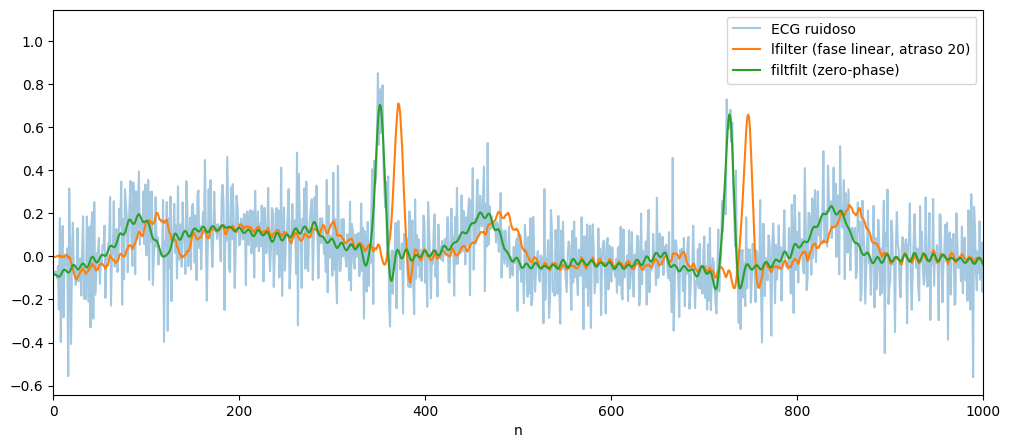

In [16]:
#Resposta da questão 3d
y_zp = sp.signal.filtfilt(h41, 1, sinal)

plt.figure(figsize=(12,5))
plt.plot(sinal, alpha=0.4, label='ECG ruidoso')
plt.plot(y_ecg, label='lfilter (fase linear, atraso 20)')
plt.plot(y_zp, label='filtfilt (zero-phase)')
plt.legend(); plt.xlabel('n')
plt.xlim(0, 1000)
plt.show()

O *zero-phase filtering* (filtrar → inverter no tempo → filtrar de novo → inverter) elimina completamente o atraso: foram medidas 20 amostras de atraso no `lfilter` contra **0** no `filtfilt`, então os picos do ECG filtrado ficam perfeitamente alinhados com os originais — crucial em ECG, onde a posição temporal dos picos é o que importa.
 
O preço é que a resposta em magnitude é aplicada duas vezes ($|H|^2$), dobrando a atenuação em dB e estreitando a banda de passagem efetiva.
